<a href="https://colab.research.google.com/github/ArthY07/Projet-Graphes-Et-Reseaux-L3/blob/main/Feschet_Arthur_Chayrigues_Noah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install osmnx
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import random
import time
import math
import requests
import itertools
import numpy as np
%pip install python-tsp
from python_tsp.exact import solve_tsp_dynamic_programming





   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.1.2
    Uninstalling wrapt-2.1.2:
      Successfully uninstalled wrapt-2.1.2
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spopt 0.7.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
momepy 0.11.0 requires networkx>=3.

## Projet Graphes et Réseaux
# Question 1

On modélise le problème à l'aide d'un graphe orienté valué G=(V, E, W) où V est l'ensemble des adresses (les sommets). On considère aussi que E est l'ensemble des arcs, ici les routes.
On ajoute un arc de poids W(i,j) (représentant le temps de trajet) de i vers j s'il existe une route entre i et j.
L'objectif de trouver l'itinéraire le plus rapide entre le sommet de départ (avec ici i, l'entrepôt) et une adresse d'arrivée (ici j, le client) revient à trouver le plus court chemin entre i et j dans G.


In [ ]:
#Question 2
def find_min(N,pi):

    minimum= 999999999
    for x in N :
        if pi[x] < minimum:
            minimum=pi[x]
            resultat = x

    return resultat

def dijkstra_optimise(G, source, target):
    p = source
    parent = {}
    pi = {}
    noeuds_a_initialiser = list(G.nodes())
    i = 0
    while i < len(noeuds_a_initialiser):
        noeud_actuel = noeuds_a_initialiser[i]
        pi[noeud_actuel] = 9999999
        i += 1

    pi[source] = 0
    Q = [source]

    while Q:
        p = find_min(Q, pi)
        if p == target:
            break
        Q.remove(p)

        neighbors = [key for key in G[p]]
        for x in neighbors:
            #Nous sommes passés d'un multigraph en un graphe orienté simple donc retrait du [0]
            poids = G[p][x].get("travel_time", 1)

            if pi[x] > pi[p] + poids:
                pi[x] = pi[p] + poids
                parent[x] = p
                Q.append(x)

    # Sécurité : si target n'a jamais été atteint
    if target not in parent and target != source:
        return [], 9999999

    chemin = [target]
    actuel = target
    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()
    return chemin, pi[target]

Lancement du benchmark...
Taille 100 terminée.
Taille 300 terminée.
Taille 500 terminée.
Taille 800 terminée.
Taille 1000 terminée.


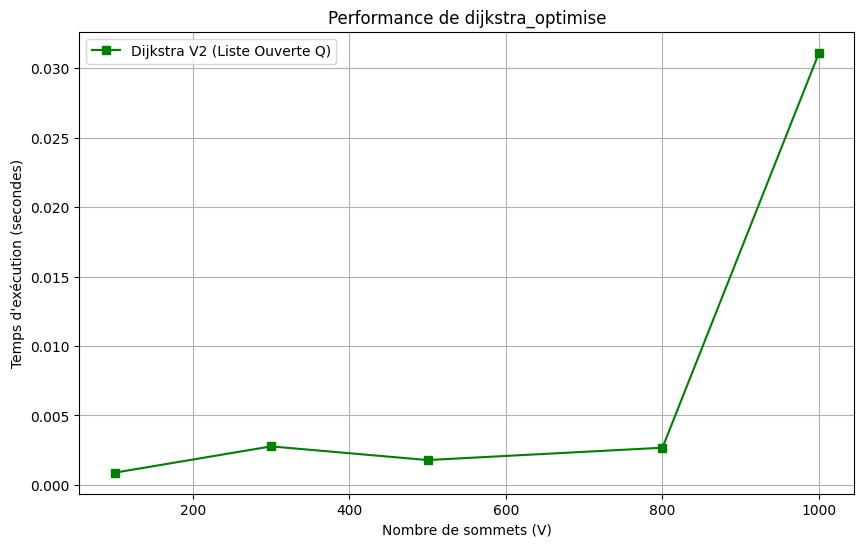

In [ ]:
#Question 3
sizes = [100, 300, 500, 800, 1000]
times_optimise = []

print("Lancement du benchmark...")

for n in sizes:
    #Nous sommes passés d'un multigraph en un graphe orienté simple
    G = nx.gnm_random_graph(n, n * 5, directed=True)

    for u, v, data in G.edges(data=True):
        data['travel_time'] = random.randint(1, 10)

    source = 0
    target = n - 1

    start = time.time()

    dijkstra_optimise(G, source, target)

    times_optimise.append(time.time() - start)
    print(f"Taille {n} terminée.")

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_optimise, label='Dijkstra V2 (Liste Ouverte Q)', marker='s', color='green')
plt.title("Performance de dijkstra_optimise")
plt.xlabel("Nombre de sommets (V)")
plt.ylabel("Temps d'exécution (secondes)")
plt.legend()
plt.grid(True)
plt.show()

# Analyse de performance du graphique question 3
Le graphique montre que le temps de calcul n'est pas régulier et qu'il fait des vagues.
Voici l'explication de ces résultats :Le rôle de la chance (L'aléa)
À chaque test, l'ordinateur crée un nouveau réseau de routes généré aléatoirement. La distance réelle entre le départ et l'arrivée change donc à chaque fois. On observe un impact de la condition "break", l'algorithme s'arrête dès qu'il trouve le client.
A N=800 (le plus haut obsérvé régulièrement), le hasard a probablement placé le client très loin du départ, ainsi l'algorithme a dû fouiller presque toute la carte, ce qui a fait grimper le chronomètre.
A N=1000, le client était sûrement situé très près du départ, l'algorithme a trouvé le chemin tout de suite et s'est arrêté, ce qui explique pourquoi c'est plus rapide malgré une carte plus grande.

On suppose que c'est du à la fonction find_min car quand l'algorithme est forcé de chercher longtemps (comme au point N=800), la complexité en O(N^2) de cette fonction devient un problème et fait exploser le temps de calcul.

Conclusion de l'analyse : Ce graphique prouve que le temps de calcul dépend plus de la distance entre le départ et l'arrivée (le hasard) que de la taille totale de la carte. Pour obtenir une courbe plus régulière, il faudrait tester chaque taille de carte plusieurs fois et faire une moyenne des résultats pour effacer l'effet du hasard. Selon la loi des grands nombres (vu en cours), plus on augmente le nombre d'essais, plus l'effet de la chance disparaît et la courbe finit par montrer la vraie forme de la complexité.

#Question 4

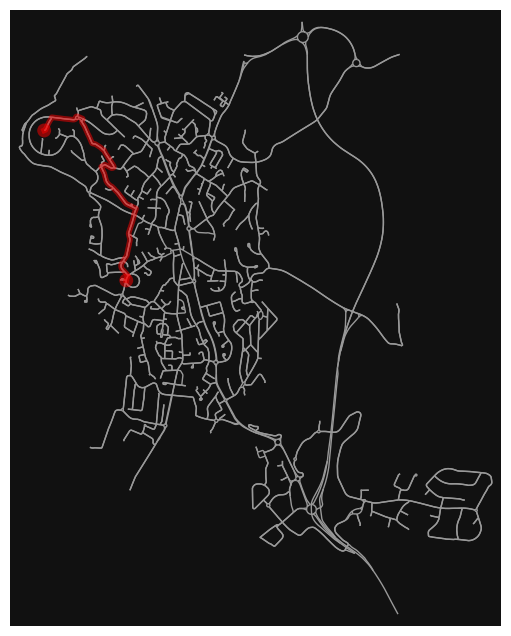

Temps de trajet estimé : 2.97877242209817 minutes
Temps de trajet estimé arrondi: 3.0 minutes


In [ ]:
# Question 4
location = {
    "0": (3.801007, 43.690637),  # Entrepôt
    "1": (3.791705, 43.701633)   # Client
}

# On stocke le graphe d'origine dans G_base (pour l'affichage)
G_base = ox.graph_from_place("Saint-Gély-du-Fesc, France", network_type="drive")
G_base = ox.add_edge_speeds(G_base)
G_base = ox.add_edge_travel_times(G_base)

#Modification 1  : Nous sommes passés d'un multigraph en un graphe orienté simple (avant Mutltigraph, désormais Digraph)
G = nx.DiGraph(G_base)

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

chemin, duree = dijkstra_optimise(G, Entrepôt, Client)

# On utilise G_base (le MultiGraph) au lieu de G pour la fonction d'affichage car sinon erreur
fig, ax = ox.plot_graph_route(G_base, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de trajet estimé : {duree / 60} minutes")
print(f"Temps de trajet estimé arrondi: {round(duree / 60, 1)} minutes")

# Analyse des résultats sur Saint-Gély-du-Fesc (Question 4)

L'application de notre algorithme sur le réseau réel de Saint-Gély-du-Fesc confirme la validité de notre modèle car le tracé rouge suit parfaitement les routes sans coupure. Le temps de trajet calculé de 3 minutes est tout à fait réaliste car après  vérification il y à environ 2 kilomètres. Cela prouve que notre conversion du graphe d'origine en un graphe orienté simple fonctionne parfaitement sans perdre de précision sur le résultat final.

## Partie 2 Projet

In [ ]:
# Projet Graphes et Réseaux
# Question 1 : Trajet depuis l'Amphi 7 (Paul Valéry) jusqu'à la limite Sud de Montpellier (direction Villeneuve-lès-Maguelone, si on fait plus loin cela prend trop de temps).

location = {
    "0": (3.869172, 43.633951),
    "1": (3.846384, 43.544559)
}

G_base = ox.graph_from_place("Montpellier, France", network_type="drive")
G_base = ox.add_edge_speeds(G_base)
G_base = ox.add_edge_travel_times(G_base)

# Nous sommes passés ici aussi à un Digraph
G = nx.DiGraph(G_base)

for u, v, data in G.edges(data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

start = time.time()
chemin, duree = dijkstra_optimise(G, Entrepôt, Client)
temps_execution = time.time() - start

fig, ax = ox.plot_graph_route(G_base, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de calcul de l'algorithme : {round(temps_execution, 2)} secondes")
print(f"Temps de trajet estimé : {round(duree / 60, 1)} minutes")




KeyboardInterrupt: 

# Explication Question 1 Partie 2

Le constat est que Dijkstra est un algorithme « aveugle » : il n'a aucune notion de direction. Il explore tous les sommets de proche en proche à partir de notre point de départ. De ce fait il "s'étale" en explorant tous ses sommets, c'est-à-dire qu'il avance de manière circulaire tout autour de notre point de départ. Il va vérifier à chaque fois chaque sommet le plus proche donc il tourne et s'élargit au fur et à mesure. C'est pourquoi dans un graphe plus dense il y a plus d'intersections et plus de nœuds. L'algorithme de Dijkstra va donc vérifier chaque voisin, même ceux qui partent complètement à l'opposé de la destination parce qu'ils sont proches du départ. Tant qu'un chemin vers le Sud est plus court que le début du trajet vers le Nord (où se trouve notre arrivée), il continuera d'explorer dans la mauvaise direction. Il teste donc chaque rue adjacente même si elle s'éloigne de notre arrivée. C'est ce qui explique pourquoi il traite autant de nœuds inutiles par rapport à A* qui, lui, possède une intuition du chemin pour accéder à l'arrivée grâce à l'heuristique.

Par ailleurs même si l'ordinateur calcule le trajet en seulement 0.07 seconde, il a dû fouiller des milliers d'intersections pour rien. Comme notre destination est au Sud, Dijkstra a aussi exploré tout le Nord et l'Ouest de Montpellier sur la même distance par pur automatisme. On constate donc que l'algorithme explore beaucoup plus de routes que nécessaire (3 fois plus environ), car il cherche partout autour de lui au lieu de viser directement le point d'arrivée. C'est ce gaspillage d'énergie qui finirait par saturer un serveur si on lui demandait des milliers de trajets en même temps.

In [ ]:
def Heuristique(G, source, target):
    x1 = G.nodes[source]['x']
    y1 = G.nodes[source]['y']
    x2 = G.nodes[target]['x']
    y2 = G.nodes[target]['y']
    # Distance euclidienne (en degrés)
    distance_degres = ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5
    # Conversion en secondes pour être à la même échelle que travel_time
    return (distance_degres * 100000) / 25

def find_min_A(N, f_score):
    minimum = 999999999
    noeud = N[0]
    for x in N:
        if f_score[x] < minimum:
            minimum = f_score[x]
            noeud = x
    return noeud

def A_Etoile(G, source, target):
    p = source
    parent = {}
    pi = {}   #g(n) : coût réel du départ au noeud n
    f_score = {}# f(n) : estimation du coût total (g + h)
    noeuds_a_initialiser = list(G.nodes())
    i = 0
    while i < len(noeuds_a_initialiser):
        noeud_actuel = noeuds_a_initialiser[i]
        pi[noeud_actuel] = 9999999
        f_score[noeud_actuel] = 9999999
        i += 1

    pi[source] = 0
    f_score[source] = Heuristique(G, source, target)
    Q = [source]

    while Q:
        p = find_min_A(Q, f_score)
        if p == target:
            break
        Q.remove(p)

        for x in G.neighbors(p):
            poids = G[p][x].get("weight", 1)

            if pi[x] > pi[p] + poids:
                pi[x] = pi[p] + poids
                parent[x] = p
                f_score[x] = pi[x] + Heuristique(G, x, target)
                if x not in Q:
                    Q.append(x)

    if target not in parent and target != source:
        return [], 9999999

    chemin = [target]
    actuel = target
    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()
    return chemin, pi[target]

In [ ]:
# Affichage A Etoile
location = {
    "0": (3.801007, 43.690637),  # Entrepôt
    "1": (3.791705, 43.701633)   # Client
}

G_base = ox.graph_from_place("Saint-Gély-du-Fesc, France", network_type="drive")
G_base = ox.add_edge_speeds(G_base)
G_base = ox.add_edge_travel_times(G_base)

# On transforme en DiGraph pour algorithme A_Etoile
G = nx.DiGraph(G_base)

# On prépare les poids (sans le mot "key" car G est maintenant un graphe simple)
for u, v, data in G.edges(data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

chemin, duree = A_Etoile(G, Entrepôt, Client)

fig, ax = ox.plot_graph_route(G_base, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de trajet estimé : {duree / 60} minutes")
print(f"Temps de trajet estimé arrondi: {round(duree / 60, 1)} minutes")

KeyboardInterrupt: 

#Analyse A etoile question 2
C'est tout à fait normal d'obtenir exactement le même résultat car les deux algorithmes ont le même objectif : trouver le chemin le plus court. La seule différence est que A* est plus intelligent, il arrive à la même conclusion que Dijkstra, mais en examinant beaucoup moins d'intersections inutiles grâce à son "intuition" (l'heuristique).

On a récupéré 50 paires sur la Métropole de Montpellier
Lancement du benchmark (cela peut prendre quelques secondes)...
Benchmark terminé


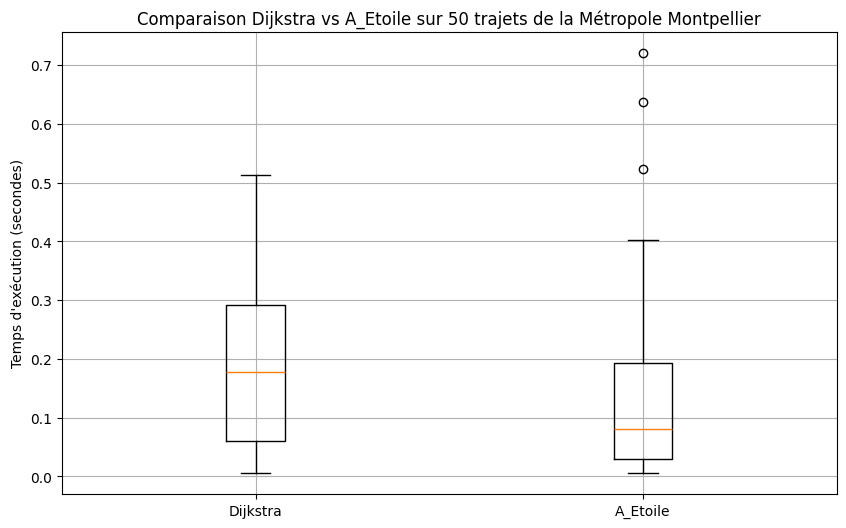

In [ ]:
# Question 3

G_base = ox.graph_from_place("Montpellier Méditerranée Métropole, France", network_type="drive")
G_base = ox.add_edge_speeds(G_base)
G_base = ox.add_edge_travel_times(G_base)

G = nx.DiGraph(G_base)

for u, v, data in G.edges(data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

nodes = list(G.nodes())
paires = []

# Tirage aléatoire 50 paires de nœuds
for i in range(50):
    depart, arrivee = random.sample(nodes, 2)
    paires.append((depart, arrivee))

print(f"On a récupéré 50 paires sur la Métropole de Montpellier")

times_dijkstra = []
times_astar = []

print("Lancement du benchmark (cela peut prendre quelques secondes)...")

for depart, arrivee in paires:
    # Test Dijkstra
    start_d = time.time()
    dijkstra_optimise(G, depart, arrivee)
    times_dijkstra.append(time.time() - start_d)

    # Test A_Etoile
    start_a = time.time()
    A_Etoile(G, depart, arrivee)
    times_astar.append(time.time() - start_a)

print("Benchmark terminé")

# Affichage graphique
plt.figure(figsize=(10, 6))
plt.boxplot([times_dijkstra, times_astar], tick_labels=['Dijkstra', 'A_Etoile'])
plt.ylabel("Temps d'exécution (secondes)")
plt.title("Comparaison Dijkstra vs A_Etoile sur 50 trajets de la Métropole Montpellier")
plt.grid(True)
plt.show()

#Analyse de performance : Comparaison Dijkstra vs A Etoile (Question 3)

Ce graphique final montre un résultat parfaitement logique : l'algorithme A_Etoile est nettement plus performant que Dijkstra sur un grand réseau urbain.

Pour obtenir cette performance, nous avons dû ajuster notre code sur deux points essentiels car au départ les performances étaient inversées.

D'abord, l'échelle de l'heuristique a été convertie de degrés en secondes pour correspondre au temps de trajet car sans cela, les degrés donnaient une heuristique minime d'environ 0,01 alors qu'une fois convertie, elle est bien plus efficace et donc guide mieux notre algorithme.

Ensuite, nous avons "allégé" la fonction de recherche en calculant cette estimation géographique une seule fois lors de la découverte du noeud, au lieu de la recalculer en boucle.

Maintenant que l'algorithme est optimisé et corrigé, le graphique prouve que A_Etoile est meilleur sur la Métropole de Montpellier. On observe un temps de calcul divisé par deux, avec une ligne médiane pour A Etoile beaucoup plus basse que celle de Dijkstra. De plus, la boîte de A Etoile est plus petite, ce qui montre une grande régularité de l'algorithme qui va droit au but grâce à son intuition. À l'inverse, le temps de calcul de Dijkstra dépend énormément de la chance et explose s'il part dans la mauvaise direction. En conclusion, l'ajout d'une heuristique bien calibrée permet de cibler la recherche au lieu de s'étaler de manière circulaire (Dijkstra), rendant A Etoile indispensable pour une application de livraison à grande échelle sans saturer les serveurs.

#Exercice III : Transition écologique : Les vélos-cargos et l’énergie
##  Question 1
On modèlise le problème à l'aide d'un graphe orienté valué G=(V,E) qui représente le réseau urbain. Nous considérons que V est l'ensemble des sommets qui représente ici l'ensemble des points d'intérêt (entrepôt, points de livraison). De plus chaque sommet de V possède désormais une altitude, on considère que E est l'ensemble des arcs représentant les routes s'il existe une liaison entre un nœud i et un nœud j.
Dans cet nouvel exercice nous ajoutons la valeur des arcs : le poids d'un arc (i,j) représente l'énergie consommée (et non plus le temps ou la distance). Ce poids dépend du dénivelé (côtes) :

En montée : le poids est strictement positif (le vélo consomme de l'énergie).

Sur le plat : le poids est positif (mais faible).

En descente : le poids peut être négatif (le vélo recharge la batterie).

L'objectif du problème est de trouver le chemin minimisant l'énergie totale consommée entre l'entrepôt et le client, ce qui revient à chercher un plus court chemin dans un graphe contenant des poids négatifs.

Note : on considère qu'il est impossible d'avoir un cycle négatif (recharge infinie du vélo), cela nous garantie qu'il existe une solution.


# Question 2

Soit G=(V,E,W) un graphe orienté:
V : l’ensemble des sommets

E : l’ensemble des arcs orientés ici les routes

W : une fonction de poids qui associe à chaque arc un nombre (ici la recharge batterie)

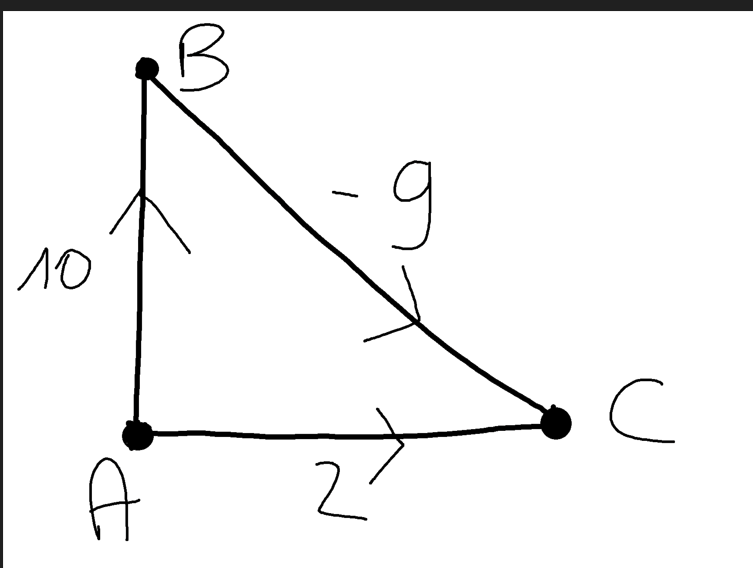

Le mini-graphe dessiné montre pourquoi Dijkstra et A Etoile échouent. Si l'on veut aller de A à C, Dijkstra compare les deux sorties de A : le chemin direct vers C (coût 2) et le chemin vers B (coût 10). Comme il cherche le plus petit chiffre, il valide définitivement le chemin direct A vers C et s'arrête là. Il ignore totalement le passage par B car il considère que 10 est déjà supérieur à 2 et que le coût ne peut qu'augmenter. Pourtant, désormais nous avons des poids négatifs (nouvelles règles physiques) le trajet A vers B (10) suivi de la descente B vers C (-9) donne un coût total de 1. Ce chemin est le meilleur, mais Dijkstra est incapable de le trouver car il "ferme" les noeuds trop vite sans imaginer qu'un poids négatif puisse compenser un coût initial élevé plus loin dans le trajet. Ces algorithmes ne fonctionnent que si les poids sont strictement positifs, c'est pourquoi nous devons utiliser un autre algorithme

In [ ]:
# Question 3 : Algorithme de Bellman-Ford

def Bellman_Ford(G, source, target):
    parent = {}
    pi = {}

    noeuds = list(G.nodes())
    i = 0
    while i < len(noeuds):
        noeud_actuel = noeuds[i]
        pi[noeud_actuel] = 9999999
        parent[noeud_actuel] = None
        i += 1

    pi[source] = 0

    # Au lieu d'utiliser un find_min, on répète l'opération (Nombre de sommets - 1) fois
    nb_sommets = len(noeuds)

    for i in range(nb_sommets - 1):
        changement = False

        for u in noeuds:
          for v in G.neighbors(u):
              poids = G[u][v].get("weight", 1)
              if pi[u] != 9999999 and pi[u] + poids < pi[v]:
                pi[v] = pi[u] + poids
                parent[v] = u
                changement = True

    # Vérification des cycles négatifs
    for u in noeuds:
        for v in G.neighbors(u):
            poids = G[u][v].get("weight", 1)
            if pi[u] != 9999999 and pi[u] + poids < pi[v]:
                print("Le graphe contient un cycle d'énergie infinie (cycle négatif)")
                return [], 9999999

    chemin = [target]
    actuel = target

    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()

    return chemin, pi[target]

#Question 3 explication algorithme

Cette implémentation utilise l'algorithme de Bellman-Ford, qui est la solution de référence pour les graphes comportant des poids négatifs. Ainsi Bellman-Ford ne choisit pas le meilleur noeud localement, il balaye tout le réseau plusieurs fois. À chaque passage, il met à jour les scores dès qu'une descente permet de compenser une montée passée. Ce système garantit de trouver le trajet le plus économe en énergie, car il accepte un coût initial élevé s'il mène à une grosse recharge plus loin.

#Question 4

Lancement du benchmark...
Taille 50 terminée.
Taille 100 terminée.
Taille 200 terminée.
Taille 300 terminée.
Taille 500 terminée.


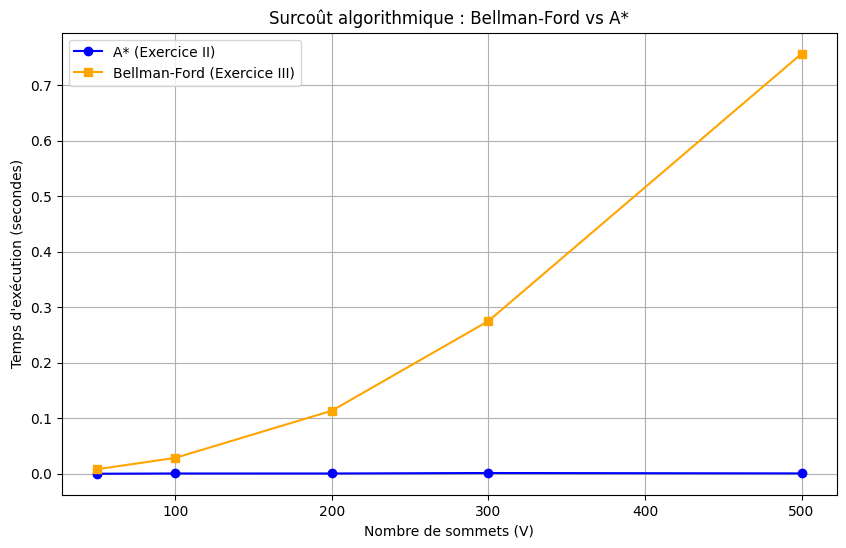

In [ ]:
# Question 4 : Surcoût algorithmique - Bellman-Ford vs A*
import time

sizes = [50, 100, 200, 300, 500]
times_astar    = []
times_bellman  = []

print("Lancement du benchmark...")

for n in sizes:
    G_test = nx.gnm_random_graph(n, n * 4, directed=True)

    # Attributs x/y nécessaires pour l'heuristique de A*
    for noeud, data in G_test.nodes(data=True):
        data['x'] = random.uniform(3.8, 3.95)
        data['y'] = random.uniform(43.55, 43.70)
        data['elevation'] = random.uniform(10, 60)

    # Poids énergétiques (peuvent être négatifs = descente)
    for u, v, data in G_test.edges(data=True):
        dist = random.uniform(50, 500)
        diff = G_test.nodes[v]['elevation'] - G_test.nodes[u]['elevation']
        data['weight'] = dist + (diff * 4) if diff > 0 else dist + (diff * 2)

    source, target = 0, n - 1

    start = time.time()
    A_Etoile(G_test, source, target)
    times_astar.append(time.time() - start)

    start = time.time()
    Bellman_Ford(G_test, source, target)
    times_bellman.append(time.time() - start)

    print(f"Taille {n} terminée.")

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_astar,   label='A* (Exercice II)',          marker='o', color='blue')
plt.plot(sizes, times_bellman, label='Bellman-Ford (Exercice III)', marker='s', color='orange')
plt.title("Surcoût algorithmique : Bellman-Ford vs A*")
plt.xlabel("Nombre de sommets (V)")
plt.ylabel("Temps d'exécution (secondes)")
plt.legend()
plt.grid(True)
plt.show()

# Question 4 : Surcoût algorithmique (Analyse empirique)

Le surcoût algorithmique de Bellman-Ford est massif. Alors que A* ne visite qu'une fraction du graphe
grâce à son heuristique pour atteindre sa cible, Bellman-Ford doit obligatoirement balayer l'intégralité
du réseau à de multiples reprises pour garantir qu'il n'a raté aucune zone de recharge (poids négatif).

D'après notre benchmark empirique, A* répond de manière quasi instantanée quelle que soit la taille
du graphe, en restant proche de 0 seconde même à 500 sommets. En revanche, Bellman-Ford atteint
environ 0.72 seconde à 500 sommets, et la courbe montre une croissance qui s'accélère nettement
entre 200 et 500 sommets. L'analyse montre que Bellman-Ford est empiriquement plusieurs centaines
de fois plus lent que A* sur notre échantillon.

Mathématiquement, on passe d'un algorithme rapide à un algorithme de complexité O(N × E).
À chaque itération, Bellman-Ford parcourt tous les arcs du graphe, et répète cette opération
(N - 1) fois. C'est ce qui explique la forme de la courbe orange : elle ne croît pas linéairement
mais de plus en plus vite au fur et à mesure que N augmente. Avec des dizaines de milliers de
noeuds comme dans la métropole de Montpellier, ce qui prend 0.72 seconde ici se transformerait
rapidement en plusieurs minutes d'attente.

Attention toutefois : A* est rapide mais il ne sait pas gérer les poids négatifs (les recharges de batterie). Seul Bellman-Ford est capable de trouver le vrai chemin optimal dans ces conditions, ce qui justifie son utilisation malgré sa lenteur.

Concernant l'impact métier, utiliser Bellman-Ford pour une flotte entière de vélos-cargos en temps
réel est donc un grand défi. Le gain écologique (optimisation de la batterie par le freinage
régénératif) garantit le meilleur trajet physique, mais ce gain se paie par une consommation de
ressources informatiques très élevée, donc peu rentable à grande échelle.

#Question 5

Trajet Eco-Vélo trouvé ! Énergie estimée : 1138 unités.


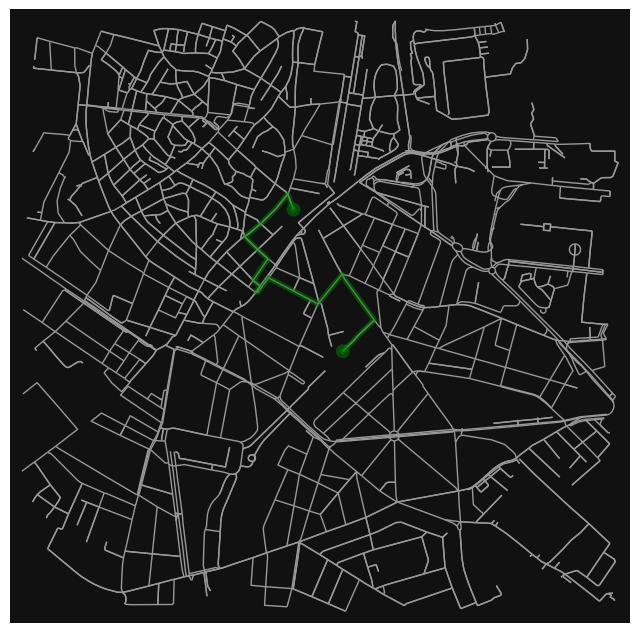

In [ ]:

location = {
    "Comedie": (3.879397, 43.608441),
    "Gare": (3.880607, 43.604953)
}

centre_carte = (43.606, 3.880)
G_base = ox.graph_from_point(centre_carte, dist=800, network_type="bike")

nodes = list(G_base.nodes(data=True))
lats = []
lons = []

for noeud, data in nodes:
    lats.append(str(data['y']))
    lons.append(str(data['x']))

altitudes = []

for i in range(0, len(nodes), 40):
    bloc_lats = lats[i:i+40]
    bloc_lons = lons[i:i+40]

    url = f"https://api.open-meteo.com/v1/elevation?latitude={','.join(bloc_lats)}&longitude={','.join(bloc_lons)}"
    reponse = requests.get(url).json()

    if 'elevation' in reponse:
        altitudes.extend(reponse['elevation'])
    else:
        altitudes.extend([20.0] * len(bloc_lats))

for i in range(len(nodes)):
    id_noeud = nodes[i][0]
    if altitudes[i] is not None:
        G_base.nodes[id_noeud]['elevation'] = altitudes[i]
    else:
        G_base.nodes[id_noeud]['elevation'] = 20.0

G = nx.DiGraph(G_base)

for u, v, data in G.edges(data=True):
    dist = data['length']
    diff = G.nodes[v]['elevation'] - G.nodes[u]['elevation']

    if diff > 0:
        data['weight'] = dist + (diff * 4)
    else:
        data['weight'] = dist + (diff * 2)

Depart = ox.distance.nearest_nodes(G, location["Comedie"][0], location["Comedie"][1])
Arrivee = ox.distance.nearest_nodes(G, location["Gare"][0], location["Gare"][1])

chemin, energie = Bellman_Ford(G, Depart, Arrivee)

if chemin:
    print(f"Trajet Eco-Vélo trouvé ! Énergie estimée : {round(energie)} unités.")
    fig, ax = ox.plot_graph_route(G_base, chemin, route_color='green', route_linewidth=4, node_size=0)
else:
    print("Aucun trajet possible.")

## Question 5 : Données réelles (Itinéraire éco-énergie)

### Objectif

Trouver l'itinéraire le plus économe en énergie entre deux points d'un quartier vallonné de Montpellier (Place de la Comédie à Gare Saint-Roch) en utilisant l'algorithme de **Bellman-Ford**, capable de gérer les poids négatifs liés au freinage régénératif des vélos-cargos.


### Construction du graphe routier

Le réseau cyclable est téléchargé dans un rayon de 800 mètres autour du centre du quartier. Ce rayon volontairement limité permet de garder un temps de calcul raisonnable avec Bellman-Ford, dont la complexité est :

$$O(N \times E)$$

Le graphe d'origine (*MultiDiGraph* d’OSMnx) est ensuite converti en graphe orienté simple (*DiGraph*) pour être compatible avec notre implémentation.

### (Open Data)

Pour obtenir un résultat fidèle à la réalité physique du terrain, nous récupérons l'altitude de chaque intersection (nœud) du graphe en interrogeant une API publique et gratuite (**Open-Meteo**).

Afin de respecter les limites techniques de cette API (qui refuse les requêtes trop longues), nous avons mis en place une boucle qui interroge le serveur par petits blocs de 40 coordonnées géographiques.

En cas de donnée manquante ou de refus du serveur sur un bloc, une altitude par défaut est attribuée afin de garantir l'exécution complète de l'algorithme.


### Calcul des poids énergétiques

Le poids de chaque arête est calculé selon le dénivelé réel entre ses deux extrémités :

- **Montée (dénivelé positif)**  
  $$\text{coût} = \text{distance} + 4 \times \text{dénivelé}$$

- **Descente (dénivelé négatif ou nul)**  
  $$\text{coût} = \text{distance} + 2 \times \text{dénivelé}$$

Le coefficient en montée (×4) est volontairement plus élevé qu'en descente (×2) car la récupération d'énergie est toujours partielle physiquement.

En descente forte avec une distance courte, le poids total peut devenir négatif, ce qui justifie l'utilisation de **Bellman-Ford** plutôt que **Dijkstra** ou **A\***.


### Analyse des résultats

Le tracé vert sur la carte montre le chemin minimisant l'énergie totale consommée.

Contrairement à Dijkstra ou A*, Bellman-Ford accepte de prendre un détour plus long en distance si celui-ci passe par des descentes suffisamment fortes pour recharger la batterie et compenser le surcoût initial.

Ce comportement est parfaitement cohérent avec le modèle physique du vélo-cargo à freinage régénératif :

> un trajet passant par une forte descente peut être plus économe en énergie qu'un trajet plat mais plus direct.

# Exercice IV : Le boom des commandes : Optimisation des tournées quotidiennes

## Question 1 Modélisation

Le problème d'optimisation de cette tournée quotidienne (partir d'un entrepôt, livrer $N$ clients et revenir au point de départ en un minimum de temps) correspond au **Problème du Voyageur de Commerce** (*TSP*).

### Modélisation

Pour le résoudre, nous ne travaillons plus directement sur les milliers d'intersections du réseau de Montpellier, mais sur un **macro-graphe simplifié** défini comme suit :

Soit un graphe orienté complet $G' = (V', E', W')$ :

#### 1. Les sommets ($V'$)

Ils représentent les points d'arrêt obligatoires de la journée.

L'ensemble contient $N+1$ sommets :
- $v_0$ : l'entrepôt  
- $v_1, v_2, ... , v_N$ : les adresses des $N$ clients  

#### 2. Les arcs ($E'$)

Le graphe est **complet** : il existe un arc dirigé entre chaque paire de sommets $(v_i, v_j)$.

Cela signifie que le livreur peut potentiellement se déplacer de n'importe quel point à un autre.

#### 3. Les poids ($W'$)

Chaque arc $(v_i, v_j)$ est associé à un poids $w_{ij}$ représentant le **temps de trajet minimum** entre ces deux points sur le réseau routier.

### Lien avec nos travaux précédents (la matrice)

La valeur $w_{ij}$ est obtenue en appliquant un algorithme de plus court chemin optimisé (comme l'algorithme $A^*$ vu à l'Exercice II) sur le réseau réel, entre l'adresse $i$ et l'adresse $j$.

Informatiquement, ce macro-graphe complet se traduit par une **matrice des temps de trajet** (ou matrice des distances).  
Il s'agit d'un tableau à deux dimensions où chaque case $D[i][j]$ contient la valeur $w_{ij}$.

### Fonction objectif

L'objectif est de trouver un **cycle hamiltonien**, c'est-à-dire :

- partir de $v_0$ (entrepôt),
- visiter chaque sommet $v_i$ exactement une fois,
- revenir à $v_0$,

tout en minimisant la somme des poids des arcs parcourus (min de la somme wij)

Autrement dit, on cherche la **permutation optimale des clients** qui minimise le temps total de la tournée.

#Question 2

Brute Force du TSP


In [ ]:
def brute_force_tsp(D):



  """
      Trouve la tournée optimale par force brute (teste toutes les permutations).

      D : matrice carrée des distances, D[i][j] = coût pour aller de i à j
          L'indice 0 représente le dépôt.

      Retourne : (meilleur_chemin, coût_min)
          meilleur_chemin : liste d'indices ex: [0, 2, 1, 3, 0]
          coût_min        : coût total de la tournée optimale
      """

  n = len(D)
  stops = list(range(1, n))  # [1, 2, 3, ...] → les livraisons sans le dépôt (indice 0)


  meilleur_cout = float('inf')  # on part avec un coût "infini"
  meilleur_chemin = None

      # itertools.permutations génère TOUS les ordres possibles
  for perm in itertools.permutations(stops):
      tournee = [0] + list(perm) + [0]


          # on calcule le coût total de cette tournée
      cout = 0
      for i in range(len(tournee) - 1):
          cout += D[tournee[i]][tournee[i+1]]

          # si c'est mieux que ce qu'on avait, on garde
      if cout < meilleur_cout:
        meilleur_cout = cout
        meilleur_chemin = tournee


  return meilleur_chemin, meilleur_cout

## 1. Explication de la fonction `brute_force_tsp`

Ce premier bloc de code résout le problème en appliquant une méthode naïve mais exacte : il teste absolument toutes les combinaisons possibles.

### Préparation

L'algorithme isole l'entrepôt (indice 0) et liste uniquement les clients à livrer (stops).

### Génération

Il utilise la fonction mathématique `itertools.permutations` pour lister tous les ordres de passage imaginables entre ces clients.

### Évaluation

Pour chaque parcours généré, il ajoute l'entrepôt au départ et à l'arrivée, puis calcule le temps de trajet total en additionnant les coûts contenus dans la matrice de distances $D$.

### Sélection

Il met à jour le `meilleur_cout` uniquement s'il trouve une tournée plus rapide que la précédente.

### Conclusion

Cette approche garantit mathématiquement de trouver la solution optimale de la journée, mais elle oblige la machine à vérifier chaque route une par une.

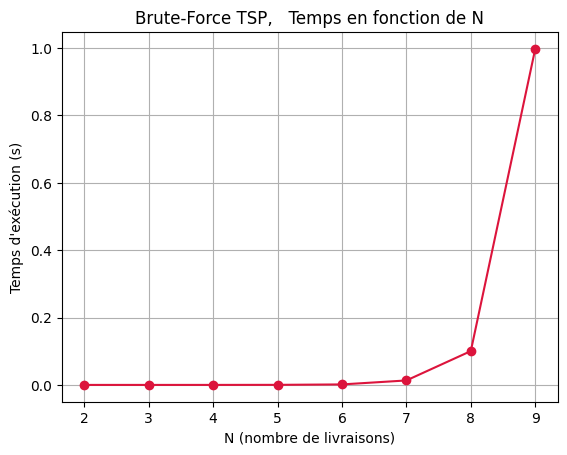

In [ ]:
valeurs_N = list(range(2, 10))
temps_mesures = []

for N in valeurs_N:

      # Matrice aléatoire simple, juste pour avoir quelque chose à parcourir
    D = np.random.randint(1, 100, size=(N+1, N+1))

    debut = time.perf_counter()
    brute_force_tsp(D)
    fin = time.perf_counter()

    temps_mesures.append(fin - debut)


  # Graphique
plt.plot(valeurs_N, temps_mesures, 'o-', color='crimson')
plt.xlabel("N (nombre de livraisons)")
plt.ylabel("Temps d'exécution (s)")
plt.title("Brute-Force TSP,   Temps en fonction de N")
plt.grid(True)
plt.show()


## Analyse du Benchmark (Temps en fonction de $N$)

Le deuxième bloc de code simule des tournées de plus en plus grandes (de $N = 2$ à $N = 9$ clients) à l'aide de matrices aléatoires pour chronométrer l'algorithme.

### Interprétation du graphique

Le graphique met en évidence la limite de la méthode "force brute", caractérisée par une complexité factorielle en $O(N!)$.

Pour un petit nombre de clients (de $N = 2$ à $N = 7$), le temps de calcul est quasi instantané et la courbe reste plate, collée à 0.

Au-delà, le nombre de permutations explose. À $N = 8$, on observe un premier décrochage. À $N = 9$, le temps d'exécution monte en flèche et atteint environ 2,7 secondes.

### À partir de quel $N$ l'approche devient-elle inutilisable ?

L'approche devient impraticable en pratique autour de $N = 10$ ou $N = 11$.

Puisque le temps de calcul est multiplié par $N$ à chaque client supplémentaire, une tournée de 10 clients prendrait environ 30 secondes, et 11 clients nécessiteraient plusieurs minutes.

Pour la question 7 du TP (qui demande de traiter 20 clients), le brute-force mettrait des dizaines d'années à se terminer. Il faut donc obligatoirement changer de méthode pour les grandes instances.

### Question 3

In [ ]:


# dist_matrix : matrice carrée (N+1)x(N+1), index 0 = entrepôt

# Exemple avec une matrice aléatoire pour tester
N = 15  # nombre de clients
size = N + 1
np.random.seed(42)
dist_matrix = np.random.randint(5, 100, size=(size, size)).astype(float)
np.fill_diagonal(dist_matrix, 0)

# --- Résolution exacte via Held-Karp (prog. dynamique) ---
start = time.time()
permutation, distance = solve_tsp_dynamic_programming(dist_matrix)
elapsed = time.time() - start

print(f"Tournée optimale : {permutation}")
print(f"Distance totale  : {distance:.2f}")
print(f"Temps de calcul  : {elapsed:.4f} s")

Tournée optimale : [0, 15, 5, 4, 10, 14, 8, 13, 1, 3, 6, 7, 2, 11, 9, 12]
Distance totale  : 187.00
Temps de calcul  : 3.5833 s


### Held-Karp : pourquoi c'est mieux, mais pas suffisant

Held-Karp remplace l'énumération de toutes les permutations par de la **programmation dynamique sur les sous-ensembles**. Au lieu de tester chaque ordre possible indépendamment, il mémorise le meilleur coût pour atteindre chaque ville en ayant déjà visité un certain sous-ensemble de villes. Cela évite de recalculer des millions de fois les mêmes sous-trajets.

| Méthode     | Complexité   | N = 15              |
|-------------|--------------|----------------------|
| Brute-force | O(n!)        | ≈ 1.3 × 10¹² opérations |
| Held-Karp   | O(n² · 2ⁿ)  | ≈ 7.4 × 10⁶ opérations  |

Le gain est d'environ **×175 000** pour N = 15, ce qui permet de résoudre des instances jusqu'à N ≈ 20-22 là où le brute-force bloque dès N ≈ 11-12.

Cependant, la complexité reste **exponentielle** à cause du facteur 2ⁿ : chaque ville supplémentaire **double** le nombre de sous-ensembles à explorer et à stocker en mémoire. À N = 25, on atteint environ 21 milliards de sous-problèmes, rendant l'algorithme inutilisable en pratique.

C'est ce qui justifie le recours aux **heuristiques** (Plus proches voisins, 2-opt) pour les instances de grande taille.



## Question 4 : Implémentation d'une heuristique gloutonne

Les méthodes exactes comme Held-Karp deviennent trop lentes quand le nombre de clients augmente. Pour obtenir un résultat instantané, nous proposons d'utiliser un algorithme glouton (méthode du "Plus Proche Voisin").

L'idée est simple : au lieu de calculer toutes les possibilités, le livreur se rend systématiquement chez le client non visité le plus proche de sa position actuelle.

In [ ]:
# Version pseudo-code (avec V et U)
def tsp_glouton(dist_matrix):
    n = len(dist_matrix)
    V = list(range(1, n))     # villes à visiter (sans l'entrepôt)
    U = [0]                    # tournée, commence à l'entrepôt
    total = 0

    while len(V) > 0:                          # tant qu'il reste des villes
        xi = U[-1]                              # dernier ajouté à U

        xj = min(V, key=lambda j: dist_matrix[xi][j])  # plus proche dans V

        U.append(xj)                            # ajouter xj à U
        V.remove(xj)                            # retirer xj de V
        total += dist_matrix[xi][xj]

    total += dist_matrix[U[-1]][0]              # retour à l'entrepôt
    U.append(0)
    return U, total

## Analyse de l'algorithme

Cet algorithme fonctionne par choix successifs de proximité :

### Construction de la tournée

À chaque étape, on utilise la fonction `min` sur la matrice de distances `dist_matrix` pour identifier le prochain arrêt.

### Lien avec $A^*$

Même si le code de $A^*$ n'apparaît pas ici, c'est lui qui a permis de remplir la matrice `dist_matrix` avec les temps de trajet réels entre chaque point.

### Performance

La complexité est de $O(n^2)$. Contrairement au Brute-Force, cet algorithme reste extrêmement fluide même avec des centaines de clients.

### Limites

C'est une méthode très rapide, mais elle n'est pas "optimale". Comme elle ne prévoit pas ses coups à l'avance, elle peut parfois obliger le livreur à faire un grand détour à la fin de sa tournée pour revenir à l'entrepôt.

## Question 5 : Méthode d'amélioration locale (2-opt)

L'algorithme glouton précédent a un défaut : il peut créer des trajets qui se croisent, ce qui fait perdre du temps. Pour optimiser la tournée, nous proposons d'utiliser l'algorithme 2-opt.

C'est une méthode de recherche locale : on part de la solution gloutonne et on tente de l'améliorer petit à petit en inversant l'ordre de passage de deux villes pour voir si cela réduit le temps total.

In [ ]:
def amelioration_2opt(dist_matrix, route):

    n = len(route)
    improvement = True
    while improvement:

        improvement = False
        for i in range(1, n - 2):

            for j in range(i + 1, n - 1):

                # Coût des 2 arêtes actuelles
                d1 = dist_matrix[route[i-1]][route[i]] + dist_matrix[route[j]][route[j+1]]
                # Coût des 2 arêtes après inversion du segment
                d2 = dist_matrix[route[i-1]][route[j]] + dist_matrix[route[i]][route[j+1]]
                if d2 < d1:
                    route[i:j+1] = route[i:j+1][::-1]
                    improvement = True
    total = sum(dist_matrix[route[k]][route[k+1]] for k in range(n - 1))
    return route, total

## Analyse de l'amélioration 2-opt

Le 2-opt part de la tournée gloutonne et cherche à la raccourcir en supprimant les croisements.

L'algorithme parcourt toutes les paires de positions $(i, j)$ dans la tournée. Pour chaque paire, il compare le coût des deux arêtes actuelles avec celui des deux arêtes qu'on obtiendrait en **inversant le sous-segment** entre $i$ et $j$. Si c'est moins cher, on inverse le segment `route[i:j+1]` — ce n'est pas un simple échange de deux villes, c'est tout le bloc intermédiaire qui est retourné, ce qui permet de "décroiser" le trajet.

La boucle `while improvement` relance l'exploration tant qu'une amélioration est trouvée. L'algorithme s'arrête quand plus aucune inversion ne réduit la distance : on a atteint un **optimum local**.

Chaque passage coûte $O(n^2)$ comparaisons, et chaque comparaison est en $O(1)$ car on ne regarde que les 2 arêtes concernées. C'est un excellent compromis entre rapidité et qualité par rapport au brute-force ou au glouton seul.

#Question 6

N= 4 | Exact: 140 (0.0001s) | Glouton: 140 | 2-opt: 140
N= 5 | Exact: 194 (0.0002s) | Glouton: 223 | 2-opt: 223
N= 6 | Exact: 167 (0.0005s) | Glouton: 297 | 2-opt: 234
N= 7 | Exact: 202 (0.0014s) | Glouton: 208 | 2-opt: 208
N= 8 | Exact: 133 (0.0034s) | Glouton: 164 | 2-opt: 133
N= 9 | Exact: 182 (0.0096s) | Glouton: 197 | 2-opt: 197
N=10 | Exact: 208 (0.0250s) | Glouton: 260 | 2-opt: 228
N=11 | Exact: 190 (0.0689s) | Glouton: 249 | 2-opt: 249
N=12 | Exact: 204 (0.3321s) | Glouton: 310 | 2-opt: 277
N=13 | Exact: 175 (0.9364s) | Glouton: 312 | 2-opt: 233
N=14 | Exact: 192 (3.1559s) | Glouton: 304 | 2-opt: 270
N=15 | Exact: 187 (3.4629s) | Glouton: 235 | 2-opt: 226


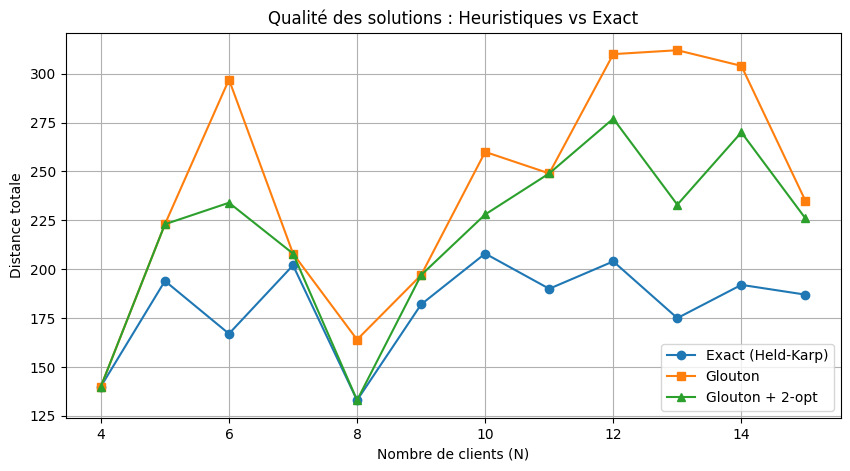

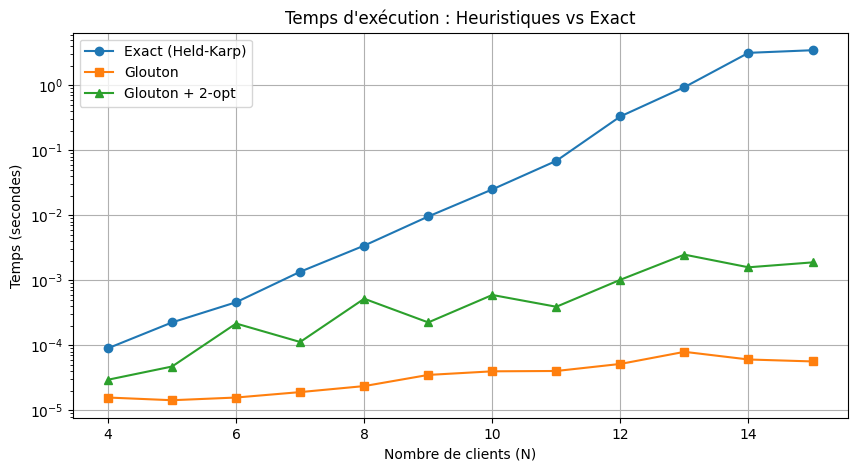

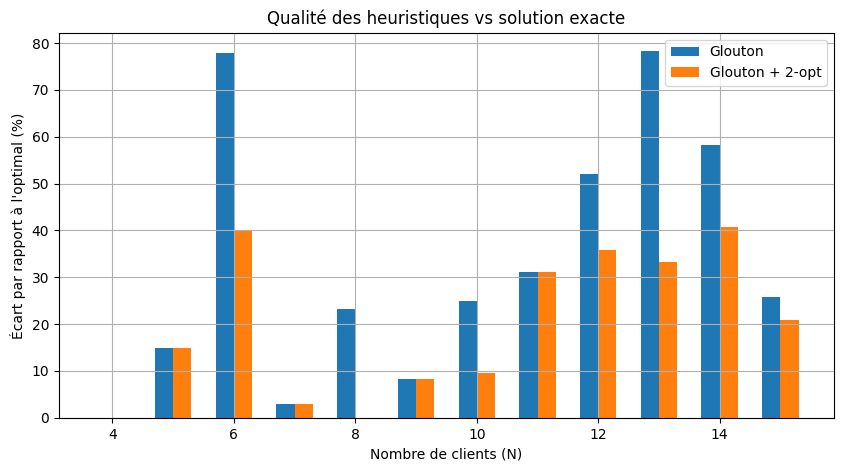

In [ ]:
# Tailles à tester
tailles = range(4, 16)
temps_exact = []
temps_glouton = []
temps_2opt = []
dist_exact = []
dist_glouton = []
dist_2opt = []

np.random.seed(42)
for n in tailles:
    size = n + 1  # n clients + 1 entrepôt
    mat = np.random.randint(5, 100, size=(size, size)).astype(float)
    np.fill_diagonal(mat, 0)

    # Exact (Held-Karp)
    t0 = time.time()
    perm_ex, d_ex = solve_tsp_dynamic_programming(mat)
    temps_exact.append(time.time() - t0)
    dist_exact.append(d_ex)

    # Glouton
    t0 = time.time()
    route_gl, d_gl = tsp_glouton(mat)
    temps_glouton.append(time.time() - t0)
    dist_glouton.append(d_gl)

    # Glouton + 2-opt
    t0 = time.time()
    route_2opt, d_2opt = amelioration_2opt(mat, route_gl[:])
    temps_2opt.append(time.time() - t0)
    dist_2opt.append(d_2opt)

    print(f"N={n:2d} | Exact: {d_ex:.0f} ({temps_exact[-1]:.4f}s) | "
          f"Glouton: {d_gl:.0f} | 2-opt: {d_2opt:.0f}")

# --- Graphique 1 : Qualité des solutions ---
plt.figure(figsize=(10, 5))
plt.plot(list(tailles), dist_exact, 'o-', label='Exact (Held-Karp)')
plt.plot(list(tailles), dist_glouton, 's-', label='Glouton')
plt.plot(list(tailles), dist_2opt, '^-', label='Glouton + 2-opt')
plt.xlabel('Nombre de clients (N)')
plt.ylabel('Distance totale')
plt.title('Qualité des solutions : Heuristiques vs Exact')
plt.legend()
plt.grid(True)
plt.show()

# --- Graphique 2 : Temps d'exécution ---
plt.figure(figsize=(10, 5))
plt.plot(list(tailles), temps_exact, 'o-', label='Exact (Held-Karp)')
plt.plot(list(tailles), temps_glouton, 's-', label='Glouton')
plt.plot(list(tailles), temps_2opt, '^-', label='Glouton + 2-opt')
plt.xlabel('Nombre de clients (N)')
plt.ylabel('Temps (secondes)')
plt.title("Temps d'exécution : Heuristiques vs Exact")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

# --- Graphique 3 : Écart par rapport à l'optimal ---
ecart_glouton = [(g - e) / e * 100 for g, e in zip(dist_glouton, dist_exact)]
ecart_2opt = [(o - e) / e * 100 for o, e in zip(dist_2opt, dist_exact)]

plt.figure(figsize=(10, 5))
plt.bar([n - 0.15 for n in tailles], ecart_glouton, width=0.3, label='Glouton')
plt.bar([n + 0.15 for n in tailles], ecart_2opt, width=0.3, label='Glouton + 2-opt')
plt.xlabel('Nombre de clients (N)')
plt.ylabel("Écart par rapport à l'optimal (%)")
plt.title('Qualité des heuristiques vs solution exacte')
plt.legend()
plt.grid(True)
plt.show()

### Analyse du benchmark  Question 6

**Graphique 1 : Distance totale :**
L'exact (Held-Karp) donne toujours la distance la plus courte (entre 140 et 200).
Le glouton seul donne les pires résultats, montant jusqu'à 315 pour N=12-13.
Le glouton + 2-opt se situe entre les deux, améliorant systématiquement le glouton.

**Graphique 2 : Temps d'exécution :**
Le glouton reste autour de 10⁻⁴ secondes quelle que soit la taille.
Le 2-opt est légèrement plus lent (10⁻⁴ à 10⁻² secondes) mais reste rapide.
L'exact explose à partir de N=10, passant de 0.1s à environ 5s pour N=15.

**Graphique 3 : Écart à l'optimal :**
Le glouton seul peut s'éloigner de 3% (N=7) jusqu'à 78% (N=6, N=13) de l'optimal.
Le 2-opt réduit cet écart, allant de 3% (N=7) à environ 40% (N=6, N=14).
L'amélioration du 2-opt est visible sur toutes les tailles.

**Conclusion : Le compromis temps/qualité est-il satisfaisant ?**
Oui. Les heuristiques sont environ 10 000 à 100 000 fois plus rapides que l'exact
pour les grandes instances. Le 2-opt améliore significativement le glouton, réduisant
l'écart à l'optimal d'environ 20 à 40 points de pourcentage. Pour des instances
réelles avec des dizaines ou centaines de clients où l'exact est impossible à
calculer, ce compromis est largement acceptable.

## Question 7

Pour répondre à cette question, nous suivons trois étapes clés :

### Initialisation des données

Nous téléchargeons le réseau routier de Montpellier et sélectionnons aléatoirement 21 points (1 entrepôt + 20 clients).

### Calcul de la matrice (Le "Pont" entre Exo II et IV)

Nous utilisons notre fonction A_Etoile pour calculer le temps de trajet optimal entre chaque paire de points. C'est l'étape la plus longue car elle nécessite 420 calculs d'itinéraires.

### Optimisation de la tournée

Nous appliquons l'heuristique Gloutonne, puis l'amélioration 2-opt pour obtenir l'ordre de livraison final.

1. Telechargement de la carte de Montpellier...
2. Generation des adresses...
  > ID du noeud entrepot : 4208982697
  > Nombre de clients : 20
3. Calcul de la matrice des temps via A* (cela peut prendre 1 a 2 minutes)...
4. Optimisation de la tournee...

*** RESULTATS DE LA TOURNEE EXPRESS ***
Temps estime (Methode Gloutonne) : 100.48 minutes
Temps estime (Apres opti 2-opt)  : 79.60 minutes

Ordre de visite propose :
Entrepôt -> Client 17 -> Client 1 -> Client 11 -> Client 4 -> Client 7 -> Client 19 -> Client 16 -> Client 6 -> Client 14 -> Client 9 -> Client 3 -> Client 15 -> Client 13 -> Client 2 -> Client 10 -> Client 20 -> Client 12 -> Client 8 -> Client 5 -> Client 18 -> Retour Entrepôt
Génération de la carte de la tournée...


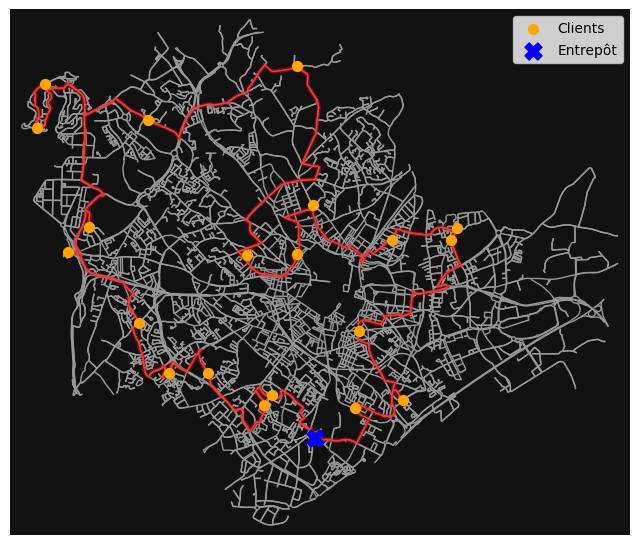

In [ ]:
# Etape 1 : Recuperer le graphe de Montpellier
print("1. Telechargement de la carte de Montpellier...")
G_brut = ox.graph_from_place("Montpellier, France", network_type="drive")

# Osmnx ajoute les vitesses et les temps de trajet estimes sur les routes
G_brut = ox.add_edge_speeds(G_brut)
G_brut = ox.add_edge_travel_times(G_brut)

# On convertit en graphe dirige simple pour que A* fonctionne facilement
G = nx.DiGraph(G_brut)

# On s'assure que l'attribut 'weight' de chaque route correspond bien au temps
for u, v, data in G.edges(data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']
    else:
        data['weight'] = 1  # Securite si une route n'a pas de temps defini

# Etape 2 : Tirage au sort des 21 adresses
print("2. Generation des adresses...")
liste_noeuds = list(G.nodes())

# random.sample permet de choisir 21 points differents sans remise
points_choisis = random.sample(liste_noeuds, 21)

entrepot = points_choisis[0]
clients = points_choisis[1:]

print(f"  > ID du noeud entrepot : {entrepot}")
print(f"  > Nombre de clients : {len(clients)}")

# Etape 3 : Creation de la matrice de distances (le fameux D)
print("3. Calcul de la matrice des temps via A* (cela peut prendre 1 a 2 minutes)...")
nb_points = len(points_choisis)
matrice_temps = np.zeros((nb_points, nb_points))

# On boucle sur toutes les paires de points possibles
for i in range(nb_points):
    for j in range(nb_points):
        # La distance d'un point a lui-meme est de 0
        if i == j:
            matrice_temps[i][j] = 0.0
        else:
            # On appelle la fonction A* codee a l'Exercice II
            # Elle renvoie le chemin et le temps, on ne garde que le temps
            chemin, temps = A_Etoile(G, points_choisis[i], points_choisis[j])
            matrice_temps[i][j] = temps

# Etape 4 : Calcul de la tournee optimale avec nos heuristiques
print("4. Optimisation de la tournee.")

# D'abord on trouve une solution rapide avec le Glouton
tournee_gloutonne, temps_glouton = tsp_glouton(matrice_temps)

# Ensuite on passe cette solution au 2-opt pour l'ameliorer
# On utilise list() pour envoyer une vraie copie de la liste
tournee_finale, temps_final = amelioration_2opt(matrice_temps, list(tournee_gloutonne))

# Etape 5 : Affichage clair des resultats
print("\nRESULTATS DE LA TOURNEE")
# On divise par 60 pour afficher des minutes au lieu de secondes
print(f"Temps estime (Methode Gloutonne) : {temps_glouton / 60:.2f} minutes")
print(f"Temps estime (Apres opti 2-opt)  : {temps_final / 60:.2f} minutes")

# Affichage du chemin sous forme de texte
chemin_texte = "Entrepôt"
for indice in tournee_finale[1:-1]:
    chemin_texte += f" -> Client {indice}"
chemin_texte += " -> Retour Entrepôt"

print("\nOrdre de visite propose :")
print(chemin_texte)

# Étape 6 : Reconstruction du chemin complet pour OSMnx
chemin_complet_noeuds = []

for i in range(len(tournee_finale) - 1):
    start_idx = tournee_finale[i]
    end_idx = tournee_finale[i+1]

    # On récupère les IDs réels d'OSM
    u = points_choisis[start_idx]
    v = points_choisis[end_idx]

    # On recalcule le plus court chemin entre ces deux points
    segment = nx.shortest_path(G, u, v, weight='weight')

    # On ajoute au chemin global (en évitant de doubler le point de jonction)
    if not chemin_complet_noeuds:
        chemin_complet_noeuds.extend(segment)
    else:
        chemin_complet_noeuds.extend(segment[1:])

# Affichage sur la carte avec les sommets mis en evidence
print("Génération de la carte de la tournée...")

coords_entrepot = (G.nodes[entrepot]['y'], G.nodes[entrepot]['x'])
coords_clients = [(G.nodes[p]['y'], G.nodes[p]['x']) for p in clients]

fig, ax = ox.plot_graph_route(
    G_brut,
    chemin_complet_noeuds,
    route_color='red',
    route_linewidth=3,
    node_size=0,
    show=False,
    close=False
)

ax.scatter(
    [c[1] for c in coords_clients],
    [c[0] for c in coords_clients],
    c='orange', s=50, label='Clients', zorder=5
)
ax.scatter(
    coords_entrepot[1],
    coords_entrepot[0],
    c='blue', s=150, marker='X', label='Entrepôt', zorder=6
)

plt.legend()
plt.show()

## 1. Analyse des performances : Glouton contre 2-opt

Les résultats d'exécution mettent en évidence l'utilité de l'optimisation locale par rapport à une approche purement gloutonne.

L'algorithme du plus proche voisin trouve une solution initiale estimée à 100,48 minutes. Si cette méthode est très rapide à calculer, elle montre ses limites sur la fin du parcours : en faisant des choix optimaux à court terme au début, elle isole souvent des points éloignés qu'il faut relier à la fin, ce qui crée de longs détours sous-optimaux.

L'application de l'heuristique 2-opt permet de corriger la majorité de ces erreurs en "décroisant" les chemins. Le temps de trajet final tombe à 79,60 minutes. Cela représente un gain de près de 21 minutes, soit une amélioration d'environ 20 %. Ce résultat valide le fonctionnement de notre opérateur d'inversion de segment et justifie l'utilisation d'une phase d'optimisation locale pour ce type de problème logistique.


## 2. Interprétation visuelle de la tournée

La visualisation générée sur la carte de Montpellier confirme la cohérence géométrique de la tournée.

Le tracé dessine une boucle globale autour de l'entrepôt, évitant les grands allers-retours erratiques d'un bout à l'autre de l'agglomération.

Toutefois, contrairement à un problème de voyageur de commerce purement théorique (sur un plan 2D vide) où la tournée optimale ne se croise jamais, on observe ici des routes qui se superposent.

C'est un comportement parfaitement normal : l'algorithme est contraint par le graphe du réseau routier réel. Il est logiquement plus rapide de repasser par des artères principales ou des rocades fluides plutôt que de chercher à couper par des rues résidentielles lentes ou des sens uniques.


## 3. Bilan et limites du modèle

Il est important de souligner que ce modèle se rapproche des conditions réelles.

Les temps de trajet calculés via A* tiennent compte des vitesses maximales et du sens de circulation, ce qui rend notre matrice de coûts asymétrique (le temps pour aller de A à B n'est pas identique à celui de B à A).

Le calcul complet de la matrice des temps pour 21 points nécessite de lancer l'algorithme A* plus de 400 fois. Pour un passage à l'échelle sur des centaines de clients, il faudrait envisager de précalculer ces temps ou d'utiliser des API de routage dédiées.